In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')

plt.style.use('dark_background')
plt.rcParams['figure.figsize'] = (14, 6)

df = pd.read_parquet('../data/features/combined_engineered.parquet')
with open('../data/features/feature_list.txt') as f:
    features = [l.strip() for l in f if l.strip()]

print(f"Feature matrix: {df.shape}")
print(f"Features: {len(features)}")
print(f"Target: log_price range: {df['log_price'].min():.3f} – {df['log_price'].max():.3f}")

Feature matrix: (2409, 37)
Features: 32
Target: log_price range: 0.049 – 3.114


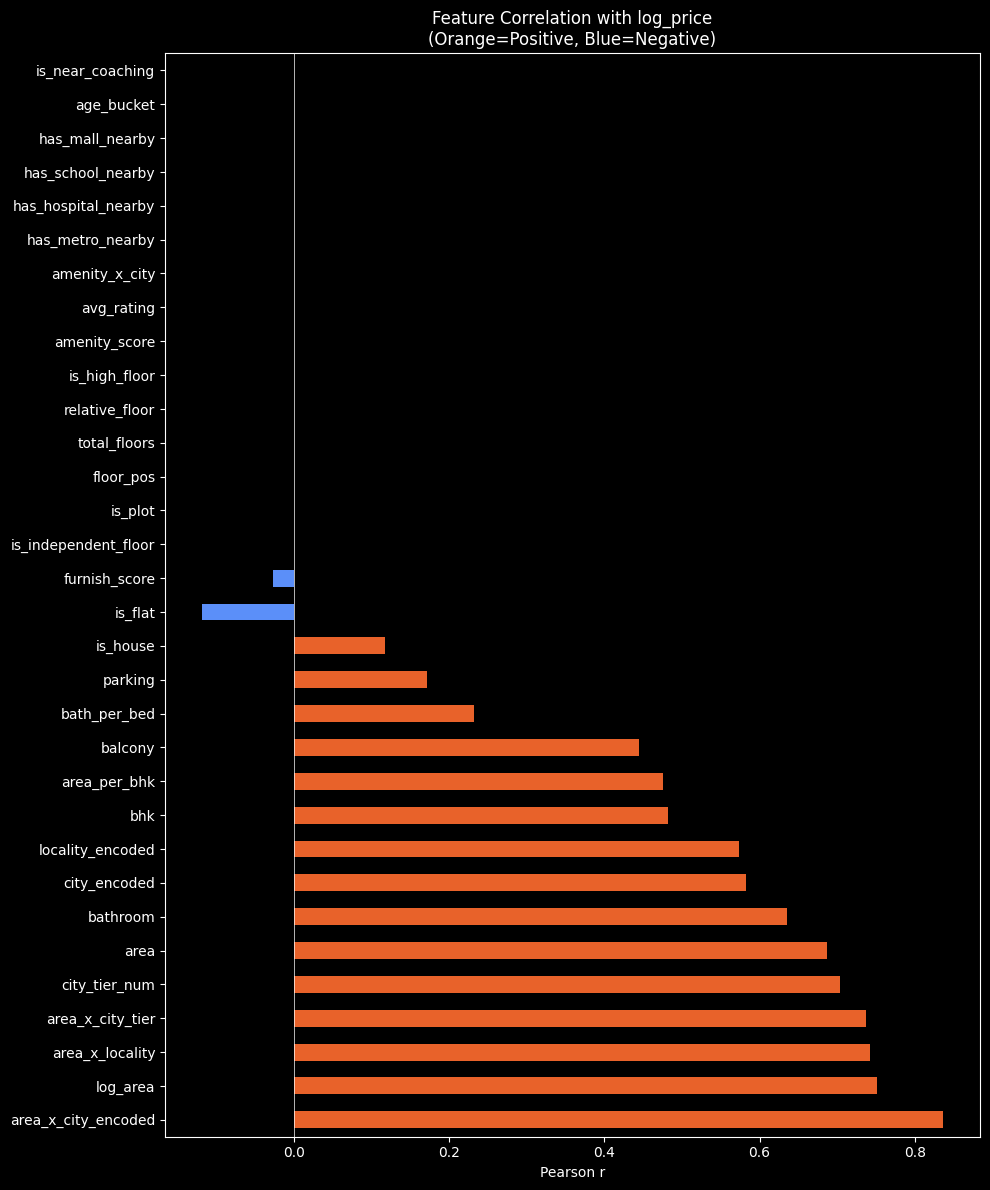


Top 10 most correlated with log_price:
area_x_city_encoded    0.836088
log_area               0.751788
area_x_locality        0.742732
area_x_city_tier       0.737550
city_tier_num          0.703477
area                   0.686296
bathroom               0.635600
city_encoded           0.582736
locality_encoded       0.574099
bhk                    0.481599

Bottom 5 (least correlated):
has_hospital_nearby   NaN
has_school_nearby     NaN
has_mall_nearby       NaN
age_bucket            NaN
is_near_coaching      NaN


In [2]:
correlations = df[features + ['log_price']].corr()['log_price'].drop('log_price')
correlations = correlations.sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 12))
colors = ['#E8622A' if v > 0 else '#5B8FF9' for v in correlations]
correlations.plot(kind='barh', ax=ax, color=colors, edgecolor='none')
ax.set_title('Feature Correlation with log_price\n(Orange=Positive, Blue=Negative)')
ax.set_xlabel('Pearson r')
ax.axvline(0, color='white', linewidth=0.5)
plt.tight_layout()
plt.savefig('../reports/feature_correlations.png', dpi=120, bbox_inches='tight')
plt.show()

print("\nTop 10 most correlated with log_price:")
print(correlations.head(10).to_string())
print("\nBottom 5 (least correlated):")
print(correlations.tail(5).to_string())

In [3]:
corr_with_target = abs(df[features].corrwith(df['log_price']))
suspicious = corr_with_target[corr_with_target >= 0.99]

if len(suspicious) > 0:
    print("⚠ POTENTIAL LEAKAGE — correlation >= 0.99:")
    print(suspicious)
else:
    print("✅ No leakage detected (no feature has |r| >= 0.99 with log_price)")

✅ No leakage detected (no feature has |r| >= 0.99 with log_price)


In [4]:
variances = df[features].var()
zero_var = variances[variances == 0]

if len(zero_var) > 0:
    print("⚠ ZERO VARIANCE features (useless for model):")
    print(zero_var)
else:
    print("✅ All features have non-zero variance")

⚠ ZERO VARIANCE features (useless for model):
is_independent_floor    0.0
is_plot                 0.0
floor_pos               0.0
total_floors            0.0
relative_floor          0.0
is_high_floor           0.0
amenity_score           0.0
avg_rating              0.0
amenity_x_city          0.0
has_metro_nearby        0.0
has_hospital_nearby     0.0
has_school_nearby       0.0
has_mall_nearby         0.0
age_bucket              0.0
is_near_coaching        0.0
dtype: float64


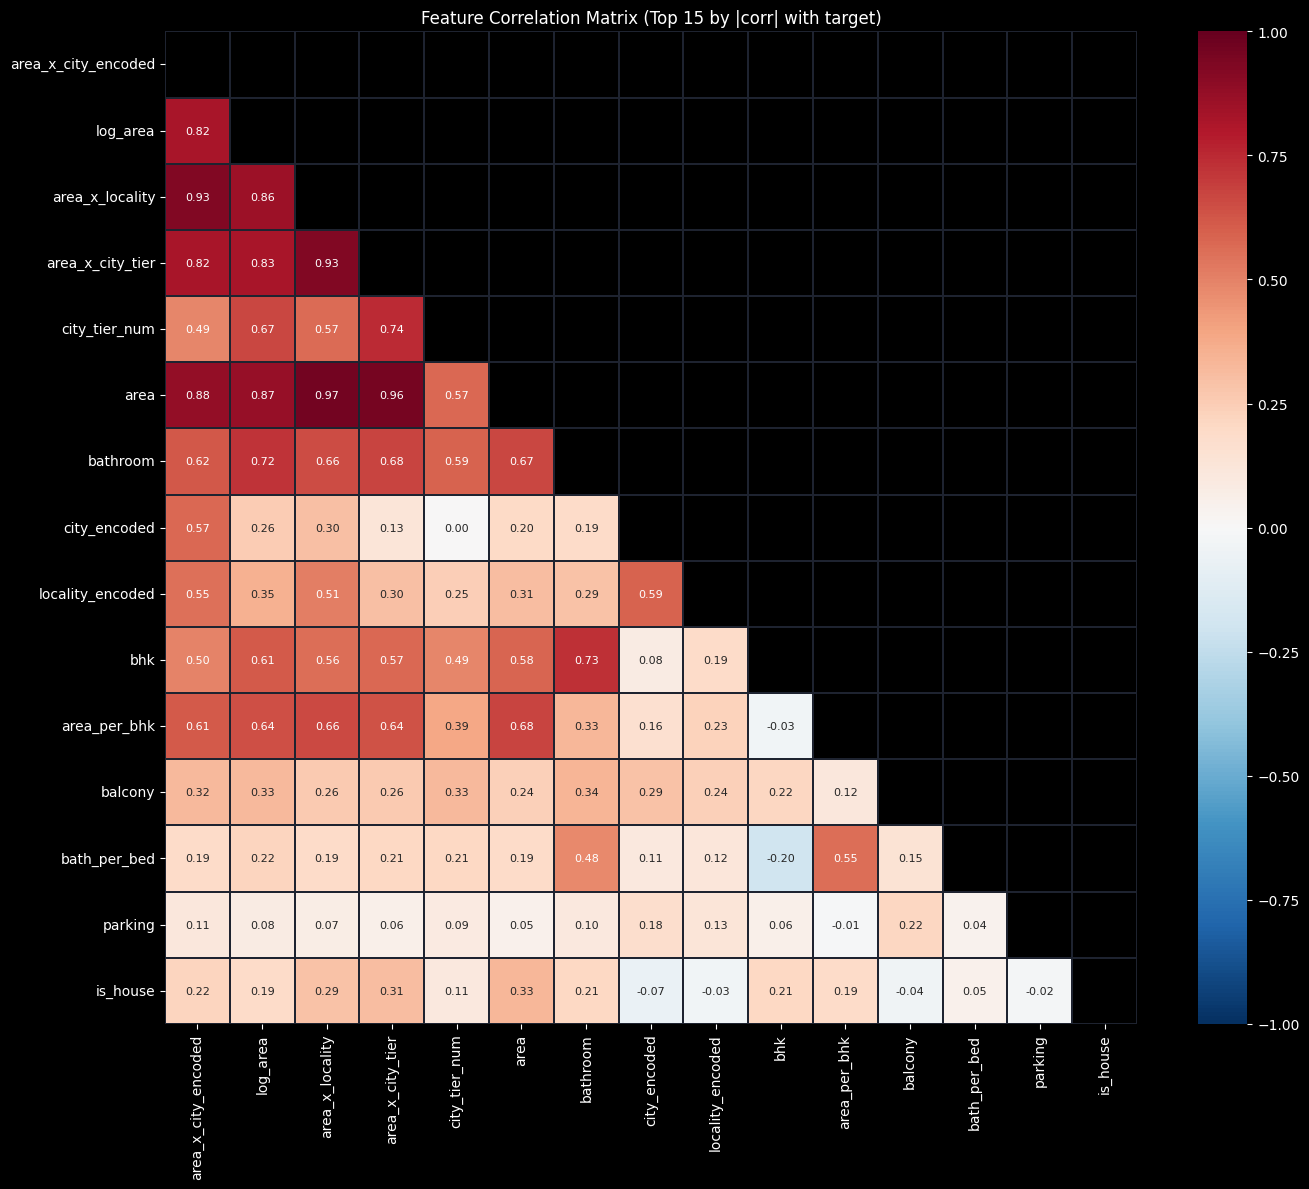

In [5]:
top15 = correlations.abs().nlargest(15).index.tolist()
corr_matrix = df[top15].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, ax=ax,
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f', annot_kws={'size': 8},
    linewidths=0.3, linecolor='#1e2330',
)
ax.set_title('Feature Correlation Matrix (Top 15 by |corr| with target)')
plt.tight_layout()
plt.savefig('../reports/feature_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

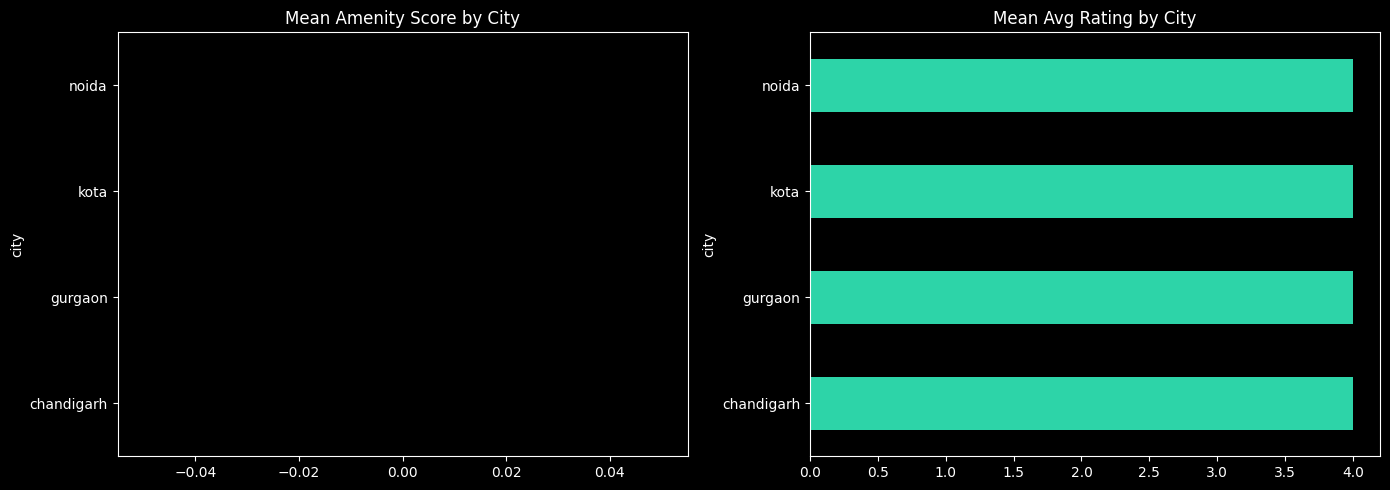

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.groupby('city')['amenity_score'].mean().sort_values().plot(
    kind='barh', ax=axes[0], color='#E8622A', edgecolor='none'
)
axes[0].set_title('Mean Amenity Score by City')

df.groupby('city')['avg_rating'].mean().sort_values().plot(
    kind='barh', ax=axes[1], color='#2DD4A8', edgecolor='none'
)
axes[1].set_title('Mean Avg Rating by City')
plt.tight_layout()
plt.savefig('../reports/quality_features_by_city.png', dpi=120, bbox_inches='tight')
plt.show()

In [7]:
import json
enc = json.load(open('../data/features/target_encoding_map.json'))
city_vals = pd.Series(enc['city_map']).sort_values()
print("City encodings (proxy for log-price level):")
print(city_vals.to_string())
print()
print("Interpretation:")
for city, val in city_vals.items():
    price_proxy = round(np.expm1(val), 2)
    print(f"  {city:15s} encoded={val:.4f}  → median price proxy ≈ ₹{price_proxy:.2f}Cr")

City encodings (proxy for log-price level):
kota          0.434264
chandigarh    0.602261
noida         0.934959
gurgaon       1.282140

Interpretation:
  kota            encoded=0.4343  → median price proxy ≈ ₹0.54Cr
  chandigarh      encoded=0.6023  → median price proxy ≈ ₹0.83Cr
  noida           encoded=0.9350  → median price proxy ≈ ₹1.55Cr
  gurgaon         encoded=1.2821  → median price proxy ≈ ₹2.60Cr


In [8]:
print("=" * 55)
print("FEATURE ENGINEERING SUMMARY")
print("=" * 55)
print(f"Total features:         {len(features)}")
print(f"Total rows:             {len(df):,}")
print(f"Feature matrix size:    {df[features].memory_usage(deep=True).sum() // 1024} KB")
print(f"NaN count (all feats):  {df[features].isna().sum().sum()}")
print(f"Max |corr| with target: {abs(correlations).max():.4f}")
print(f"Min |corr| with target: {abs(correlations).min():.4f}")
print(f"\nFeature list:")
for i, f in enumerate(features, 1):
    print(f"  {i:2d}. {f}")

FEATURE ENGINEERING SUMMARY
Total features:         32
Total rows:             2,409
Feature matrix size:    602 KB
NaN count (all feats):  0
Max |corr| with target: 0.8361
Min |corr| with target: 0.0269

Feature list:
   1. city_tier_num
   2. city_encoded
   3. area_x_city_encoded
   4. locality_encoded
   5. area_x_city_tier
   6. is_house
   7. is_flat
   8. is_independent_floor
   9. is_plot
  10. area
  11. log_area
  12. area_x_locality
  13. area_per_bhk
  14. bhk
  15. bathroom
  16. bath_per_bed
  17. floor_pos
  18. total_floors
  19. relative_floor
  20. is_high_floor
  21. amenity_score
  22. avg_rating
  23. furnish_score
  24. amenity_x_city
  25. has_metro_nearby
  26. has_hospital_nearby
  27. has_school_nearby
  28. has_mall_nearby
  29. age_bucket
  30. balcony
  31. parking
  32. is_near_coaching
